# 🧠 Drug Consumption Dataset — Exploratory Data Analysis

**Dataset :** UCI Drug Consumption (Quantified)  
**Objectif :** Explorer les distributions des traits de personnalité, les profils démographiques et les habitudes de consommation de substances.

---


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE   = "#1F4E79"
LBLUE  = "#2E75B6"
ACCENT = "#E8F4FD"
DRUGS_PALETTE = "YlOrRd"


## 1. Chargement des données

In [ ]:
COLS = [
    'ID', 'age', 'gender', 'education', 'country', 'ethnicity',
    'nscore', 'escore', 'oscore', 'ascore', 'cscore', 'impulsive', 'ss',
    'alcohol', 'amphet', 'amyl', 'benzos', 'caff', 'cannabis', 'choc',
    'coke', 'crack', 'ecstasy', 'heroin', 'ketamine', 'legalh', 'lsd',
    'meth', 'mushrooms', 'nicotine', 'semer', 'vsa'
]

df = pd.read_csv('../DATA/drug_consumption.csv', header=0, names=COLS)

# Supprimer le Semeron (drogue fictive — 8 over-claimers)
df = df[df['semer'] == 'CL0'].drop(columns=['semer', 'ID']).reset_index(drop=True)

print(f"Shape : {df.shape}")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'drug_consumption.csv'

In [ ]:
# Aperçu rapide
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1876 entries, 0 to 1875
Data columns (total 30 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1876 non-null   float64
 1   gender     1876 non-null   float64
 2   education  1876 non-null   float64
 3   country    1876 non-null   float64
 4   ethnicity  1876 non-null   float64
 5   nscore     1876 non-null   float64
 6   escore     1876 non-null   float64
 7   oscore     1876 non-null   float64
 8   ascore     1876 non-null   float64
 9   cscore     1876 non-null   float64
 10  impulsive  1876 non-null   float64
 11  ss         1876 non-null   float64
 12  alcohol    1876 non-null   object 
 13  amphet     1876 non-null   object 
 14  amyl       1876 non-null   object 
 15  benzos     1876 non-null   object 
 16  caff       1876 non-null   object 
 17  cannabis   1876 non-null   object 
 18  choc       1876 non-null   object 
 19  coke       1876 non-null   object 
 20  crack   

In [ ]:
# Vérification des valeurs manquantes
missing = df.isnull().sum()
print("Valeurs manquantes :")
print(missing[missing > 0] if missing.any() else "✅ Aucune valeur manquante")


Valeurs manquantes :
✅ Aucune valeur manquante


## 2. Décodage des variables démographiques

Les variables démographiques sont encodées numériquement par les auteurs. On les reconvertit en labels lisibles.

In [ ]:
age_map = {
    -0.95197: "18-24", -0.07854: "25-34", 0.49788: "35-44",
     1.09449: "45-54",  1.82213: "55-64",  2.59171: "65+"
}
gender_map    = {-0.48246: "Femme", 0.48246: "Homme"}
education_map = {
    -2.43591: "< 16 ans",  -1.73790: "< 17 ans",  -1.43719: "< 18 ans",
    -1.22751: "18 ans",    -0.61576: "Professionnel", -0.05921: "Université (sans diplôme)",
     0.45468: "Licence",    1.16365: "Master",         1.98437: "Doctorat"
}
country_map = {
    -0.09765: "Australie", 0.24923: "Canada", -0.46841: "Nouvelle-Zélande",
    -0.28519: "Autre",      0.21128: "Irlande",  0.96082: "UK", -0.57009: "USA"
}

df_labels = df.copy()
df_labels['age']       = df_labels['age'].map(age_map)
df_labels['gender']    = df_labels['gender'].map(gender_map)
df_labels['education'] = df_labels['education'].map(education_map)
df_labels['country']   = df_labels['country'].map(country_map)

df_labels.head(3)


,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,vsa
0,25-34,Femme,Doctorat,UK,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL0,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0
1,35-44,Femme,Université (sans diplôme),UK,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0
2,18-24,Homme,Master,UK,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0


## 3. Profil Démographique

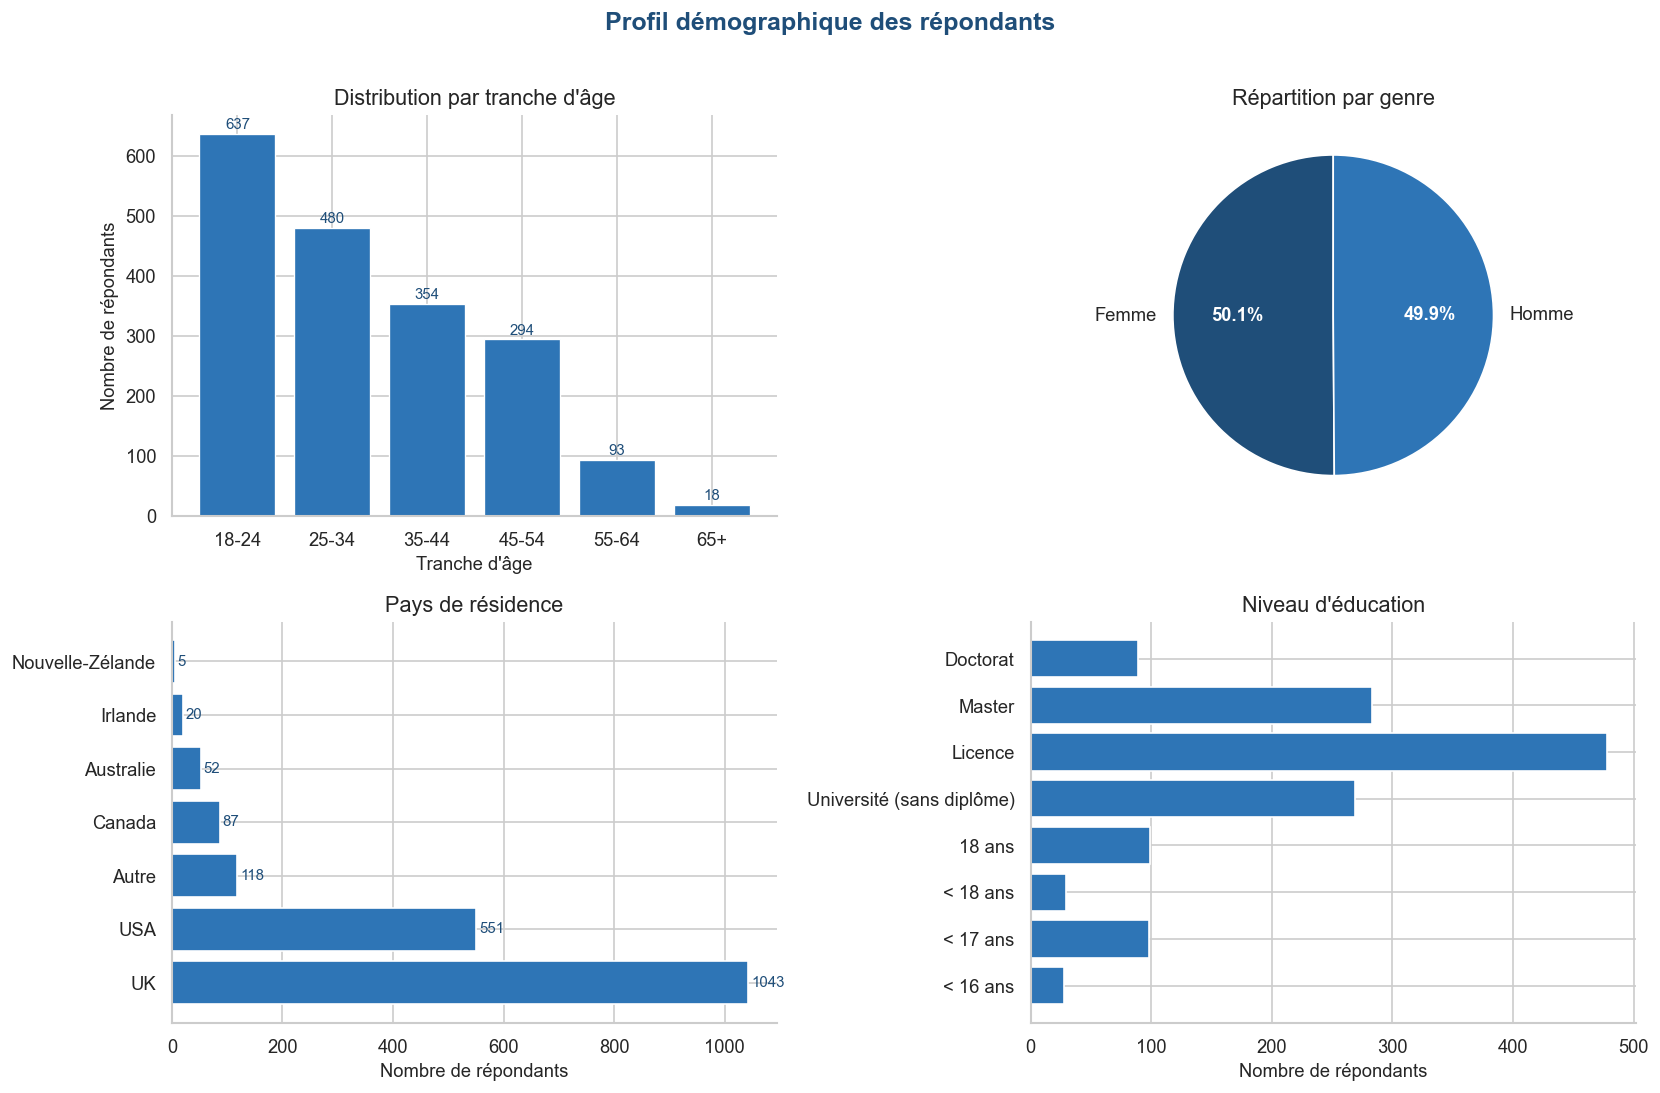

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Profil démographique des répondants", fontsize=15, fontweight='bold', color=BLUE, y=1.01)

# Age
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
age_counts = df_labels['age'].value_counts().reindex(age_order)
axes[0,0].bar(age_counts.index, age_counts.values, color=LBLUE, edgecolor='white', linewidth=0.8)
axes[0,0].set_title("Distribution par tranche d'âge")
axes[0,0].set_xlabel("Tranche d'âge")
axes[0,0].set_ylabel("Nombre de répondants")
for i, v in enumerate(age_counts.values):
    axes[0,0].text(i, v + 8, f'{v}', ha='center', fontsize=9, color=BLUE)

# Genre
gender_counts = df_labels['gender'].value_counts()
colors_g = [LBLUE, ACCENT]
wedges, texts, autotexts = axes[0,1].pie(
    gender_counts.values, labels=gender_counts.index,
    autopct='%1.1f%%', colors=[BLUE, LBLUE],
    startangle=90, textprops={'fontsize': 11}
)
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
axes[0,1].set_title("Répartition par genre")

# Pays
country_counts = df_labels['country'].value_counts()
axes[1,0].barh(country_counts.index, country_counts.values, color=LBLUE, edgecolor='white')
axes[1,0].set_title("Pays de résidence")
axes[1,0].set_xlabel("Nombre de répondants")
for i, v in enumerate(country_counts.values):
    axes[1,0].text(v + 5, i, str(v), va='center', fontsize=9, color=BLUE)

# Éducation
edu_order = ["< 16 ans", "< 17 ans", "< 18 ans", "18 ans",
             "Professionnel", "Université (sans diplôme)", "Licence", "Master", "Doctorat"]
edu_counts = df_labels['education'].value_counts().reindex(edu_order).dropna()
axes[1,1].barh(edu_counts.index, edu_counts.values, color=LBLUE, edgecolor='white')
axes[1,1].set_title("Niveau d'éducation")
axes[1,1].set_xlabel("Nombre de répondants")

plt.tight_layout()
plt.show()


## 4. Distribution des Scores de Personnalité (Big Five + Impulsivité + Sensation-Seeking)

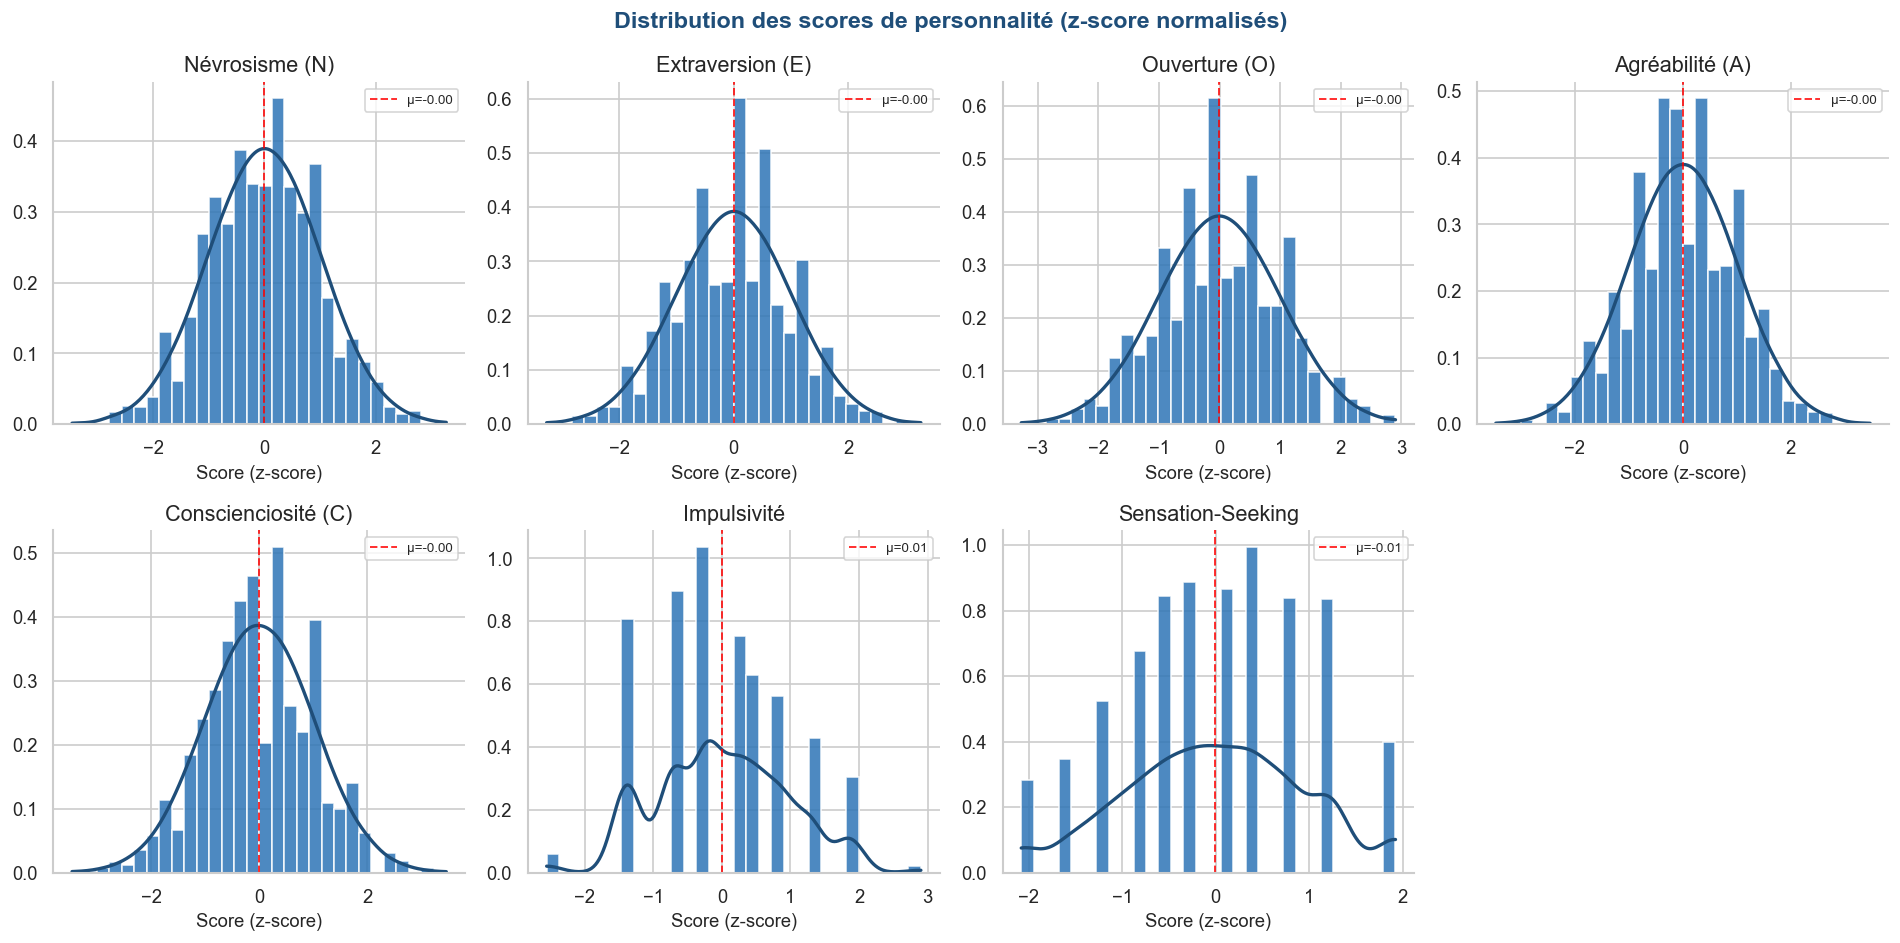

In [ ]:
personality_cols = ['nscore', 'escore', 'oscore', 'ascore', 'cscore', 'impulsive', 'ss']
personality_labels = {
    'nscore':    'Névrosisme (N)',
    'escore':    'Extraversion (E)',
    'oscore':    "Ouverture (O)",
    'ascore':    'Agréabilité (A)',
    'cscore':    'Conscienciosité (C)',
    'impulsive': 'Impulsivité',
    'ss':        'Sensation-Seeking'
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Distribution des scores de personnalité (z-score normalisés)", fontsize=14, fontweight='bold', color=BLUE)
axes = axes.flatten()

for i, col in enumerate(personality_cols):
    ax = axes[i]
    data = df[col]
    ax.hist(data, bins=30, color=LBLUE, edgecolor='white', alpha=0.85, density=True)
    # Courbe de densité manuelle (KDE)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, kde(x), color=BLUE, linewidth=2)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, alpha=0.8, label=f'μ={data.mean():.2f}')
    ax.set_title(personality_labels[col])
    ax.set_xlabel("Score (z-score)")
    ax.legend(fontsize=8)

axes[-1].set_visible(False)  # Cacher la 8e case vide
plt.tight_layout()
plt.show()


## 5. Prévalence d'usage par substance

Les labels CL0→CL6 représentent la récence d'usage : `CL0` = jamais, `CL1` = il y a plus de 10 ans, ..., `CL6` = dans la dernière journée.

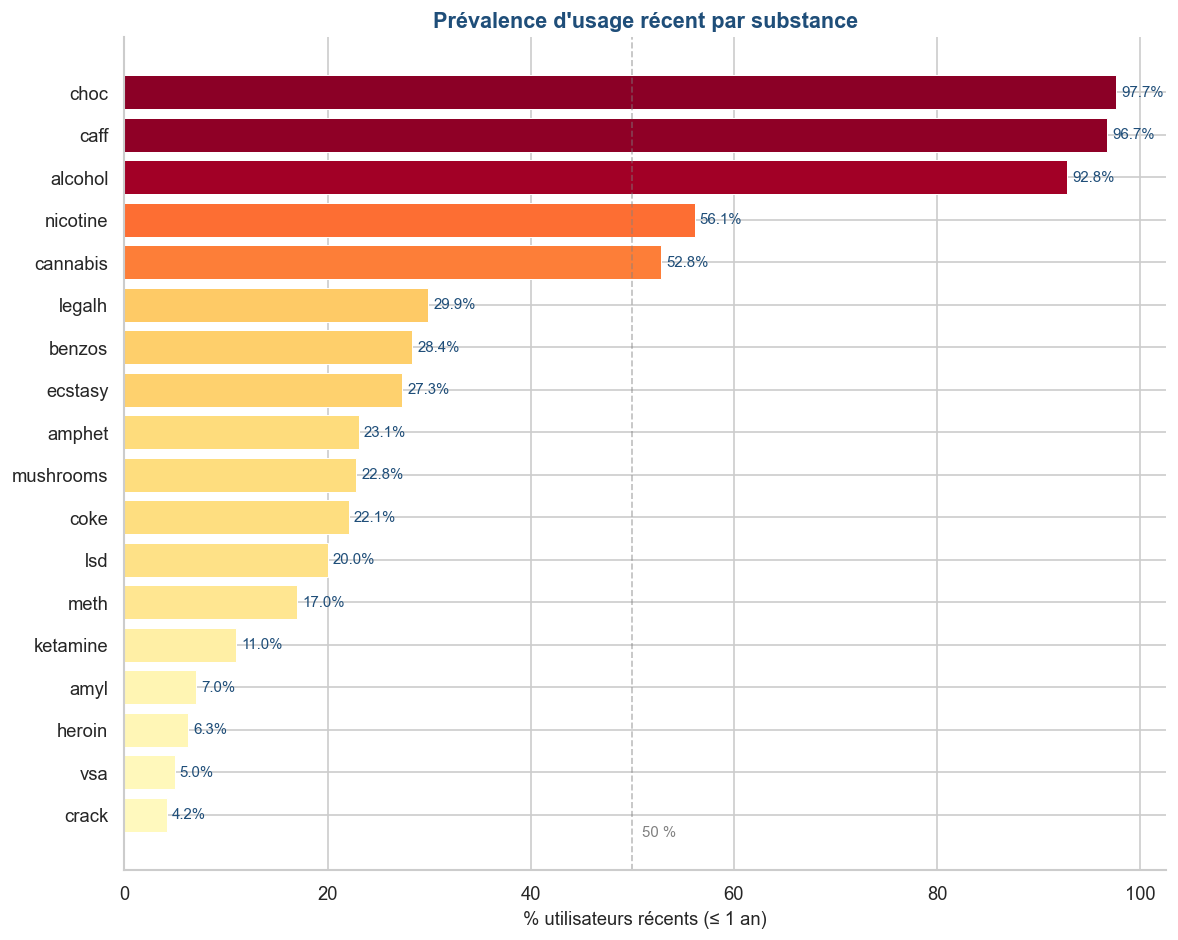

In [ ]:
drug_cols = ['alcohol', 'amphet', 'amyl', 'benzos', 'caff', 'cannabis', 'choc',
             'coke', 'crack', 'ecstasy', 'heroin', 'ketamine', 'legalh', 'lsd',
             'meth', 'mushrooms', 'nicotine', 'vsa']

CL_ORDER = ['CL0','CL1','CL2','CL3','CL4','CL5','CL6']
CL_LABELS = ['Jamais','> 10 ans','Dernière décennie','Dernière année',
             'Dernier mois','Dernière semaine','Dernier jour']

# % d'utilisateurs récents (CL3+) par drogue
recent_pct = {}
for d in drug_cols:
    recent_pct[d] = (df[d].isin(['CL3','CL4','CL5','CL6'])).mean() * 100

recent_df = pd.DataFrame({'substance': list(recent_pct.keys()), 'pct': list(recent_pct.values())})
recent_df = recent_df.sort_values('pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(recent_df['substance'], recent_df['pct'],
               color=plt.cm.YlOrRd(recent_df['pct'].values / 100),
               edgecolor='white', linewidth=0.6)

ax.set_xlabel("% utilisateurs récents (≤ 1 an)", fontsize=11)
ax.set_title("Prévalence d'usage récent par substance", fontsize=13, fontweight='bold', color=BLUE)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(51, -0.5, '50 %', color='gray', fontsize=9)

for bar, val in zip(bars, recent_df['pct'].values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color=BLUE)

plt.tight_layout()
plt.show()


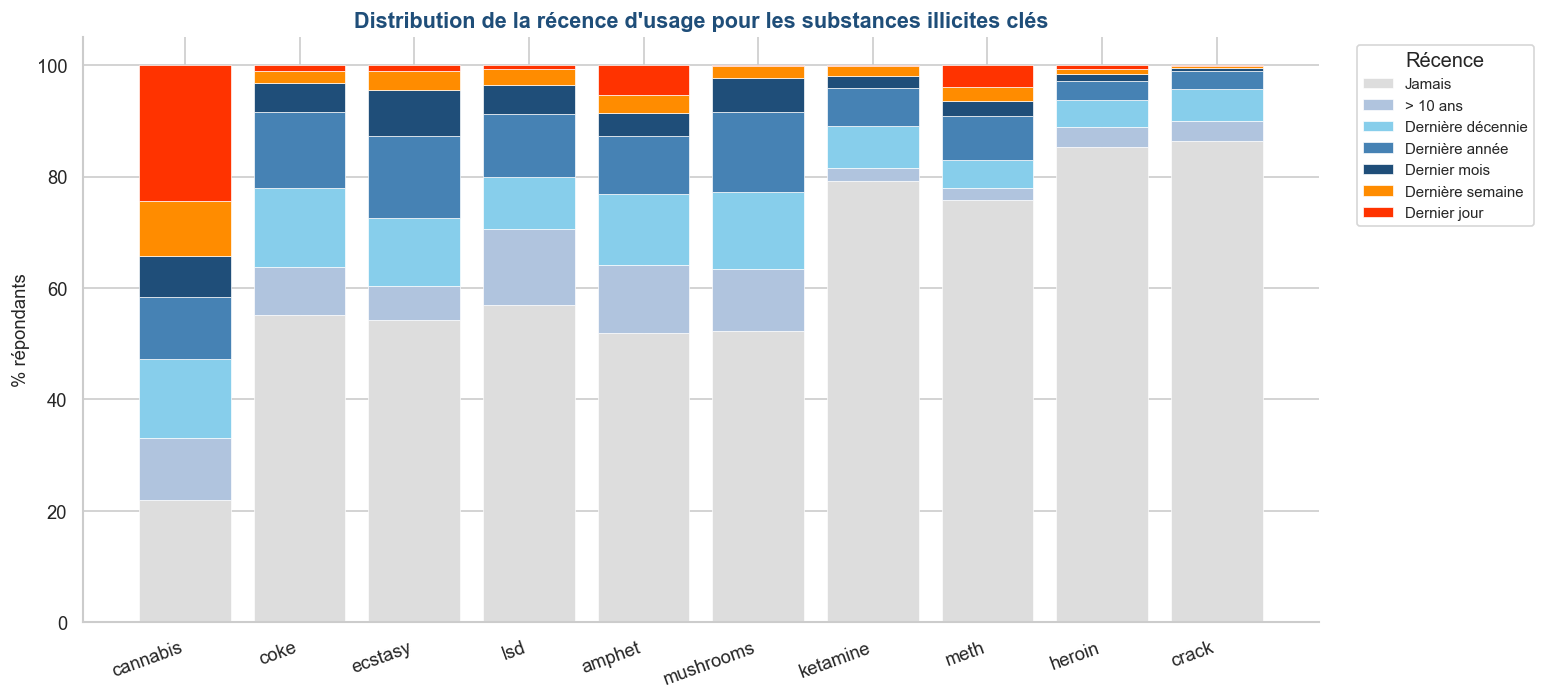

In [ ]:
# Stacked bar chart — distribution complète CL0→CL6 pour les drogues illicites clés
key_drugs = ['cannabis', 'coke', 'ecstasy', 'lsd', 'amphet', 'mushrooms',
             'ketamine', 'meth', 'heroin', 'crack']

cl_colors = ['#DDDDDD','#B0C4DE','#87CEEB','#4682B4','#1F4E79','#FF8C00','#FF3300']

dist_data = {}
for d in key_drugs:
    counts = df[d].value_counts()
    dist_data[d] = [counts.get(cl, 0) / len(df) * 100 for cl in CL_ORDER]

dist_df = pd.DataFrame(dist_data, index=CL_ORDER).T

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(key_drugs))
for i, (cl, color, label) in enumerate(zip(CL_ORDER, cl_colors, CL_LABELS)):
    vals = dist_df[cl].values
    bars = ax.bar(dist_df.index, vals, bottom=bottom, color=color,
                  label=label, edgecolor='white', linewidth=0.4)
    bottom += vals

ax.set_ylabel("% répondants", fontsize=11)
ax.set_title("Distribution de la récence d'usage pour les substances illicites clés", fontsize=13, fontweight='bold', color=BLUE)
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1), title="Récence", fontsize=9)
ax.set_ylim(0, 105)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 7. Déséquilibre de classes — Enjeu pour la Modélisation

Analyse du ratio utilisateurs/non-utilisateurs pour définir la stratégie de traitement du déséquilibre.

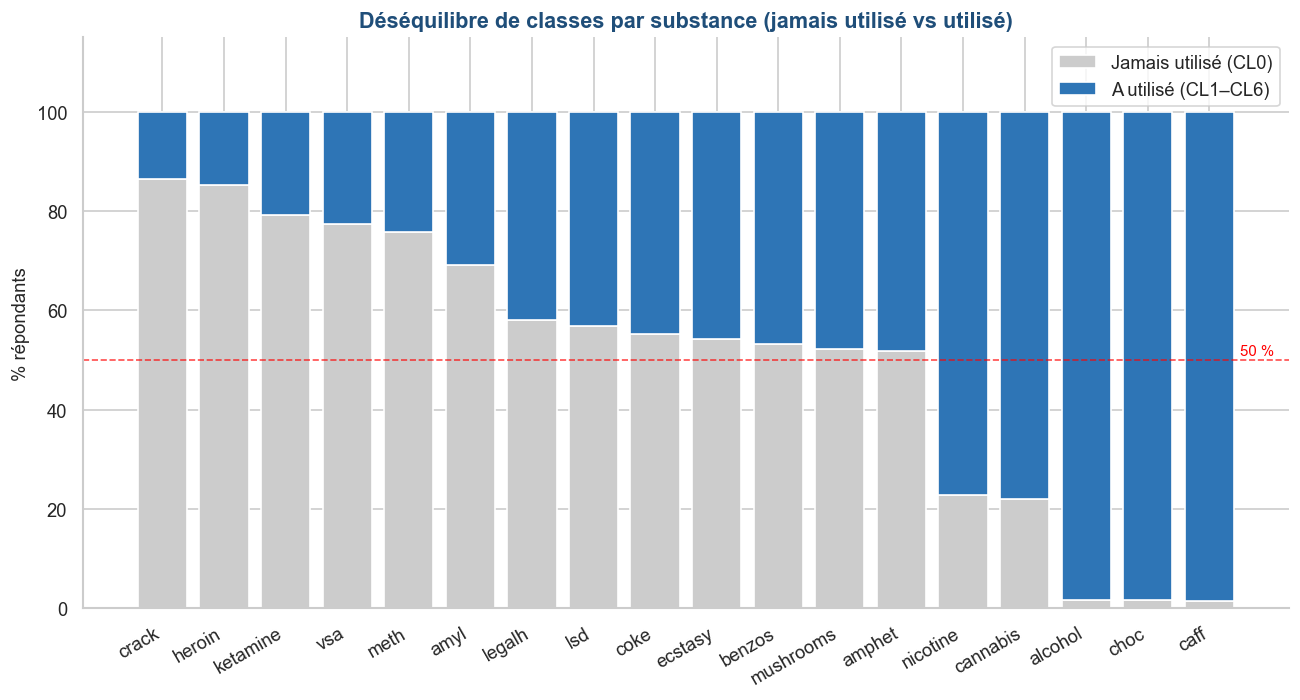


⚠️  Substances à fort déséquilibre (> 70 % jamais utilisé) :
   crack        : 86.4% jamais utilisé → nécessite SMOTE / class_weight
   heroin       : 85.2% jamais utilisé → nécessite SMOTE / class_weight
   ketamine     : 79.3% jamais utilisé → nécessite SMOTE / class_weight
   vsa          : 77.3% jamais utilisé → nécessite SMOTE / class_weight
   meth         : 75.9% jamais utilisé → nécessite SMOTE / class_weight


In [ ]:
# Ratio d'imbalance : % jamais utilisé (CL0) par substance
never_pct = {}
for d in drug_cols:
    never_pct[d] = (df[d] == 'CL0').mean() * 100

imbalance_df = pd.DataFrame({
    'substance': list(never_pct.keys()),
    'never_pct': list(never_pct.values()),
    'user_pct':  [100 - v for v in never_pct.values()]
}).sort_values('never_pct', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(imbalance_df))
ax.bar(x, imbalance_df['never_pct'],  color='#CCCCCC', label='Jamais utilisé (CL0)', edgecolor='white')
ax.bar(x, imbalance_df['user_pct'], bottom=imbalance_df['never_pct'],
       color=LBLUE, label='A utilisé (CL1–CL6)', edgecolor='white')

ax.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.text(len(imbalance_df)-0.5, 51, '50 %', color='red', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(imbalance_df['substance'], rotation=30, ha='right')
ax.set_ylabel("% répondants")
ax.set_title("Déséquilibre de classes par substance (jamais utilisé vs utilisé)", fontsize=13, fontweight='bold', color=BLUE)
ax.legend(loc='upper right')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

print("\n⚠️  Substances à fort déséquilibre (> 70 % jamais utilisé) :")
hard = imbalance_df[imbalance_df['never_pct'] > 70]
for _, row in hard.iterrows():
    print(f"   {row['substance']:12s} : {row['never_pct']:.1f}% jamais utilisé → nécessite SMOTE / class_weight")


## 8. Tableau de Synthèse

In [ ]:
summary_rows = []
for d in drug_cols:
    never  = (df[d] == 'CL0').mean() * 100
    recent = df[d].isin(['CL3','CL4','CL5','CL6']).mean() * 100
    mode   = df[d].value_counts().idxmax()
    summary_rows.append({
        'Substance':        d,
        'Jamais utilisé %': f"{never:.1f}%",
        'Usage récent %':   f"{recent:.1f}%",
        'Label le + fréquent': mode,
        'Déséquilibre ?':  '⚠️ Oui' if never > 70 else '✅ OK'
    })

summary = pd.DataFrame(summary_rows).set_index('Substance')
summary


,Jamais utilisé %,Usage récent %,Label le + fréquent,Déséquilibre ?
Substance,,,,
alcohol,1.8%,92.8%,CL5,✅ OK
amphet,51.9%,23.1%,CL0,✅ OK
amyl,69.2%,7.0%,CL0,✅ OK
benzos,53.3%,28.4%,CL0,✅ OK
caff,1.4%,96.7%,CL6,✅ OK
cannabis,22.0%,52.8%,CL6,✅ OK
choc,1.7%,97.7%,CL6,✅ OK
coke,55.2%,22.1%,CL0,✅ OK
crack,86.4%,4.2%,CL0,⚠️ Oui


---
## ✅ Conclusions EDA

| Observation | Impact sur la modélisation |
|---|---|
| **Zéro valeur manquante** | Pas d'imputation nécessaire |
| **8 over-claimers (Semeron)** | Supprimés avant modélisation |
| **Genre parfaitement équilibré** | Pas de biais démographique à corriger |
| **Skew jeunes adultes (18–34 : 60%)** | Généralisation limitée aux 55+ |
| **Cannabis & Nicotine (~50/50)** | Cibles de classification idéales |
| **Heroin & Crack (>85% CL0)** | SMOTE + class_weight obligatoires |
| **Ouverture & Sensation-Seeking** | Traits les plus discriminants (utilisateurs psychédéliques) |
| **Conscienciosité** | Corrélation négative avec usage de drogues dures |
